2025-10-07 10:30:23.269665: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-07 10:30:23.294329: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-07 10:30:23.294358: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-07 10:30:23.294370: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 10:30:23.299624: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-07 10:30:23.300577: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

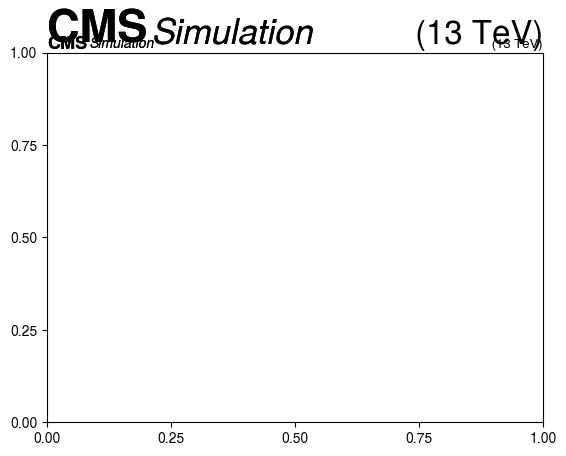

In [1]:
from tagger.plot.basic import *
import os
import numpy as np

In [ ]:
def basic(model, signal_dirs):
    """
    Plot the basic ROCs for different classes. Does not reflect L1 rate
    Returns a dictionary of ROCs for each class
    """
    model.class_labels = signal_dirs
    plot_dir = os.path.join(model.output_directory, "plots/training")

    ROC_dict = {class_label: 0 for class_label in model.class_labels}

    # Load the testing data
    X_test = np.load(f"{model.output_directory}/testing_data/X_test_constits.npy")[:1000]
    y_test = np.load(f"{model.output_directory}/testing_data/y_test.npy")[:1000]
    #truth_pt_test = np.load(f"{model.output_directory}/testing_data/truth_pt_test.npy")
    #reco_pt_test = np.load(f"{model.output_directory}/testing_data/reco_pt_test.npy")

    model_outputs = model.jet_model.predict(X_test)

    # Get classification outputs
    y_pred = model_outputs
    #pt_ratio = model_outputs[1][:, 0]

    # Plot ROC curves
    ROC_dict = ROC(y_pred, y_test, model.class_labels, plot_dir, ROC_dict)
    class_pairs = []
    # Generate all possible pairs of classes
    for i in signal_dirs:
        for j in signal_dirs:
            if i != j:
                class_pair = [i, j]
                class_pairs.append(class_pair)
    # Make ROC binaries for complete test set and each signal process
    for i in range(-1, len(signal_dirs), 1):
        sample_plot_dir = os.path.join(model.output_directory, "plots/physics", f"binary_rocs_{signal_dirs[i]}")
        if i == -1:
            y_p, y_t = y_pred, y_test
            process_label = None
        else:
            signal_indices, sample_train, sample_test = filter_process(X_test, signal_dirs[i])
            sample_data = np.concatenate((sample_train[0], sample_test[0]), axis=0)
            sample_labels = np.concatenate((sample_train[1], sample_test[1]), axis=0)
            sample_preds = model.jet_model.predict(sample_data)[0]
            y_p, y_t = y_pred[signal_indices], y_test[signal_indices]
            #process_label = process_labels(signal_dirs[i])
            os.makedirs(binary_dir, exist_ok=True)

        # Plot the binary ROCs for each class pair
        for class_pair in class_pairs:
            binary_dir = os.path.join(sample_plot_dir, f"test_set") if i != -1 else plot_dir
            ROC_binary(y_p, y_t, model.class_labels, binary_dir, class_pair, None)
            if i != -1:
                binary_dir = os.path.join(sample_plot_dir, "full_sample")
                ROC_binary(sample_preds, sample_labels, signal_dirs, binary_dir, class_pair, process_label)

        # Add light vs b/charm/gluon combined plot
        binary_dir_test = os.path.join(sample_plot_dir, "test_set") if i != -1 else plot_dir
        ROC_jets(y_p, y_t, model.class_labels, binary_dir_test, process_label)
        ROC_taus(y_p, y_t, model.class_labels, binary_dir_test, process_label)

        if i != -1:
            binary_dir_full = os.path.join(sample_plot_dir, "full_sample")
            ROC_jets(sample_preds, sample_labels, model.class_labels, binary_dir_full, process_label)
            ROC_taus(sample_preds, sample_labels, model.class_labels, binary_dir_full, process_label)

    # Efficiencies
    #efficiency(y_pred, y_test, reco_pt_test, model.class_labels, plot_dir)

    # Confusion matrix
    confusion(y_pred, y_test, model.class_labels, plot_dir)

    # Plot pt corrections
    #t_correction_hist(pt_ratio, truth_pt_test, reco_pt_test, plot_dir)

    # Plot input distributions
    plot_input_vars(X_test, model.input_vars, plot_dir)

    # Plot inclusive response and individual flavor
    #response(model.class_labels, y_test, truth_pt_test, reco_pt_test, pt_ratio, plot_dir)

    # Plot the rms of the residuals vs pt
    #rms(model.class_labels, y_test, truth_pt_test, reco_pt_test, pt_ratio, plot_dir)

    # Plot the shaply feature importance
    plot_shaply(model, X_test, model.class_labels, model.input_vars, plot_dir)

    return ROC_dict

In [9]:
from tagger.model.common import *

model = fromFolder("output/testmodel/")
model.class_labels = ['gluon' ,'quark', 'w', 'z', 't']
plot_dir = os.path.join(model.output_directory, "plots/training")

ROC_dict = {class_label: 0 for class_label in model.class_labels}

# Load the testing data
X_test = np.load(f"{model.output_directory}/testing_data/X_test_constits.npy")
y_test = np.load(f"{model.output_directory}/testing_data/y_test.npy")
#truth_pt_test = np.load(f"{model.output_directory}/testing_data/truth_pt_test.npy")
#reco_pt_test = np.load(f"{model.output_directory}/testing_data/reco_pt_test.npy")

model_outputs = model.jet_model.predict(X_test)

# Get classification outputs
y_pred = model_outputs
#pt_ratio = model_outputs[1][:, 0]

# Plot ROC curves
ROC_dict = ROC(y_pred, y_test, model.class_labels, plot_dir, ROC_dict)

/home/alex/miniconda3/envs/tagger/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


3875/3875 [==============================] - 21s 5ms/step
(124000, 5) (124000, 5)
(124000, 5) (124000, 5)
(124000, 5) (124000, 5)
(124000, 5) (124000, 5)
(124000, 5) (124000, 5)
